# Churn Prediction Pipeline — EDA
## Contexto de Negocio
Una empresa de telecomunicaciones quiere identificar clientes con riesgo 
de abandono (churn) antes de que ocurra, para que el equipo de retención 
pueda actuar de forma proactiva. Predecir el churn 30 días antes puede 
reducir significativamente el coste de adquisición de nuevos clientes.

**Problema:** Clasificación binaria — ¿abandonará este cliente en los 
próximos 30 días?

## Descripción del Dataset
**Fuente:** IBM Telco Customer Churn (Kaggle)  
**Filas:** 7.043 clientes | **Columnas:** 21 variables

### Variables del dataset

| Variable | Tipo | Descripción |
|---|---|---|
| customerID | str | Identificador único del cliente — no predictiva, se eliminará |
| gender | str | Género del cliente (Male/Female) |
| SeniorCitizen | int | Si el cliente es mayor de 65 años (0/1) |
| Partner | str | Si tiene pareja (Yes/No) |
| Dependents | str | Si tiene personas a cargo (Yes/No) |
| tenure | int | Meses como cliente de la compañía |
| PhoneService | str | Si tiene servicio telefónico (Yes/No) |
| MultipleLines | str | Si tiene múltiples líneas (Yes/No/No phone service) |
| InternetService | str | Tipo de internet (DSL/Fiber optic/No) |
| OnlineSecurity | str | Si tiene seguridad online contratada |
| OnlineBackup | str | Si tiene backup online contratado |
| DeviceProtection | str | Si tiene protección de dispositivos |
| TechSupport | str | Si tiene soporte técnico contratado |
| StreamingTV | str | Si tiene streaming de TV contratado |
| StreamingMovies | str | Si tiene streaming de películas contratado |
| Contract | str | Tipo de contrato (Month-to-month/One year/Two year) |
| PaperlessBilling | str | Si tiene factura electrónica (Yes/No) |
| PaymentMethod | str | Método de pago (Electronic check/etc.) |
| MonthlyCharges | float | Cargo mensual en dólares |
| TotalCharges | str | Cargo total acumulado — viene como str, requiere conversión |
| Churn | str | **TARGET** — Si el cliente abandonó (Yes/No) |

### Variables por categoría de negocio
- **Perfil del cliente:** gender, SeniorCitizen, Partner, Dependents
- **Relación con la empresa:** tenure, Contract, PaperlessBilling, PaymentMethod
- **Servicios contratados:** PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies
- **Facturación:** MonthlyCharges, TotalCharges

## 1. Carga y validación inicial
Verificamos shape, tipos de datos, nulos y duplicados antes de 
cualquier análisis. Esto nos da una foto del estado real de los datos.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Path al dataset
DATA_PATH = Path("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Carga
df = pd.read_csv(DATA_PATH)

# Validación inicial
print(f"Shape: {df.shape}")
print(f"\nTipos de datos:\n{df.dtypes}")
print(f"\nNulos por columna:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nDuplicados: {df.duplicated().sum()}")
df.head()

Shape: (7043, 21)

Tipos de datos:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Nulos por columna:
Series([], dtype: int64)

Duplicados: 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


- **Shape:** 7.043 filas × 21 columnas — tamaño manejable, no requiere 
  procesamiento distribuido
- **TotalCharges:** viene como `str` en lugar de `float` — indica valores 
  con espacios en blanco que pandas no detecta como nulos. Requiere 
  conversión y revisión
- **Sin duplicados ni nulos explícitos** — dataset relativamente limpio

## 2. Análisis del Target (Churn)
El target es la variable 'Churn' - si el cliente abandonó o no.
Lo primero es entender el desbalance de clases, ya que esto condiciona todas las decisiones de modelado posteriores.

Distribución del target:
       count  percentage
Churn                   
No      5174       73.46
Yes     1869       26.54


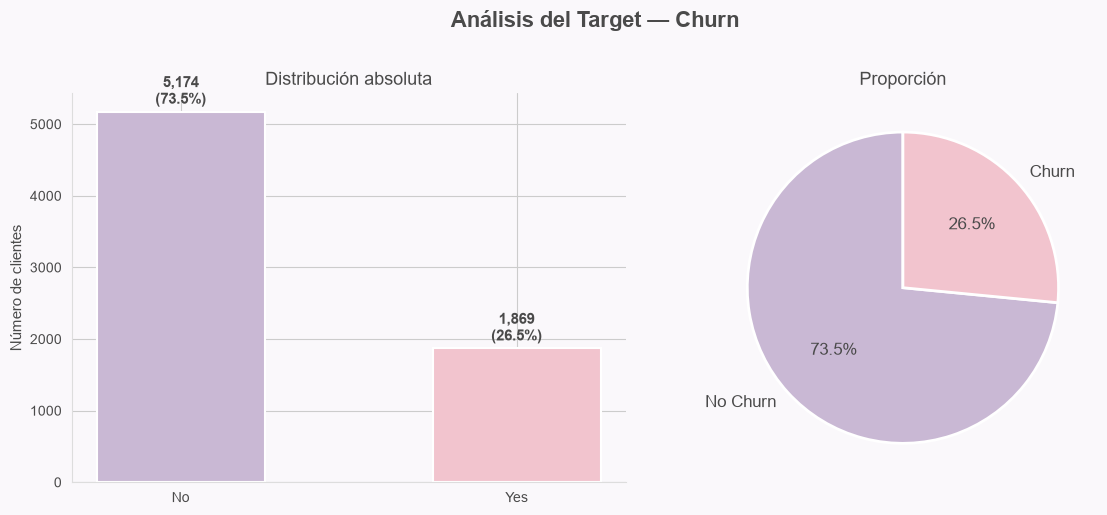

In [23]:
# Paleta armónica — definida aquí para usar en todo el notebook
PALETTE = {"No": "#C9B8D4", "Yes": "#F2C4CE"}
COLORS = ["#C9B8D4", "#F2C4CE"]
SINGLE_COLOR = "#C9B8D4"
BACKGROUND = "#FAF8FB"

# Convertir Churn a binario
df["Churn_binary"] = (df["Churn"] == "Yes").astype(int)

churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

print("Distribución del target:")
print(pd.DataFrame({"count": churn_counts, "percentage": churn_pct.round(2)}))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor=BACKGROUND)
fig.suptitle("Análisis del Target — Churn", fontsize=16, fontweight="bold", 
             color="#4A4A4A", y=1.02)

# Barplot
for ax in axes:
    ax.set_facecolor(BACKGROUND)

bars = axes[0].bar(churn_counts.index, churn_counts.values, 
                   color=COLORS, width=0.5, edgecolor="white", linewidth=1.5)
axes[0].set_title("Distribución absoluta", fontsize=13, color="#4A4A4A")
axes[0].set_xlabel("")
axes[0].set_ylabel("Número de clientes", fontsize=11, color="#4A4A4A")
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].spines[["left", "bottom"]].set_color("#DDDDDD")
axes[0].tick_params(colors="#4A4A4A")
for bar, pct in zip(bars, churn_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{bar.get_height():,.0f}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontsize=11, 
                 fontweight='bold', color="#4A4A4A")

# Pie chart
axes[1].pie(churn_counts.values, labels=["No Churn", "Churn"],
            colors=COLORS, autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2),
            textprops={"fontsize": 12, "color": "#4A4A4A"})
axes[1].set_title("Proporción", fontsize=13, color="#4A4A4A")

plt.tight_layout()
plt.savefig("../data/processed/01_target_distribution.png", dpi=150, 
            bbox_inches="tight", facecolor=BACKGROUND)
plt.show()

- **26.5% de churn** — desbalance moderado (ratio 73/27). No es extremo 
  pero es suficiente para afectar a los modelos si no se trata
- Con este desbalance, un modelo que prediga siempre "No churn" tendría 
  73% de accuracy — métrica completamente engañosa
- **Decisión:** no usaremos accuracy como métrica principal. 
  Usaremos **ROC-AUC, Precision, Recall y F1** sobre la clase minoritaria
- **Decisión:** evaluaremos tres estrategias para el desbalance:
  `class_weight='balanced'` en el modelo, SMOTE, y ajuste de threshold

## 3. Calidad del Dato — TotalCharges
`TotalCharges` viene como `str` cuando debería ser numérica.
Esto indica valores no numéricos (espacios en blanco) que pandas 
no detecta como nulos. Investigamos cuántos hay y qué clientes son.

Filas con TotalCharges vacío: 11

Detalle de clientes afectados:
      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No

Nulos tras conversión: 11


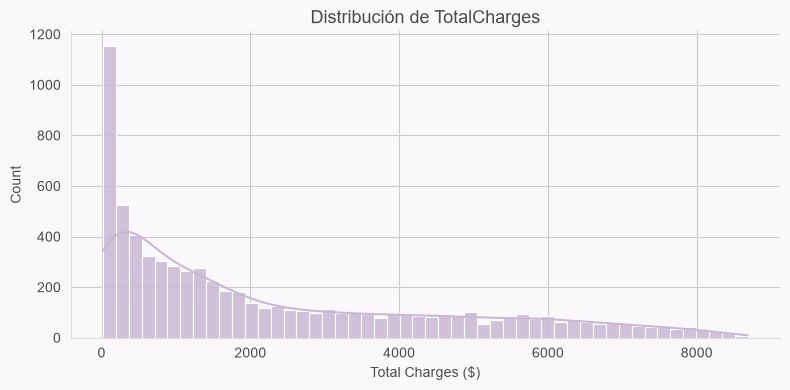

In [24]:
# Identificar valores problemáticos
total_charges_issues = df[df["TotalCharges"].str.strip() == ""]
print(f"Filas con TotalCharges vacío: {len(total_charges_issues)}")
print(f"\nDetalle de clientes afectados:")
print(total_charges_issues[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

# Convertir a numérico
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(f"\nNulos tras conversión: {df['TotalCharges'].isna().sum()}")

# Paleta armónica
SINGLE_COLOR = "#C9B8D4"
BACKGROUND = "#FAF8FB"

# Distribución de TotalCharges ya limpia
fig, ax = plt.subplots(figsize=(8, 4), facecolor=BACKGROUND)
ax.set_facecolor(BACKGROUND)
sns.histplot(df["TotalCharges"].dropna(), bins=50, kde=True, 
             color=SINGLE_COLOR, alpha=0.85, ax=ax)
ax.set_title("Distribución de TotalCharges", fontsize=13, color="#4A4A4A")
ax.set_xlabel("Total Charges ($)", color="#4A4A4A")
ax.set_ylabel("Count", color="#4A4A4A")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#DDDDDD")
ax.tick_params(colors="#4A4A4A")
plt.tight_layout()
plt.savefig("../data/processed/02_totalcharges_distribution.png", 
            dpi=150, bbox_inches="tight", facecolor=BACKGROUND)
plt.show()

- **11 filas** con TotalCharges vacío — representan el 0.15% del dataset
- **Patrón claro:** todos tienen `tenure = 0` → son clientes nuevos que 
  aún no han generado ningún cargo total en el sistema
- **No es un error de datos** — es un caso de negocio: clientes que 
  acaban de contratar y cuyo primer ciclo de facturación no ha cerrado
- La distribución de TotalCharges muestra **sesgo a la derecha** — 
  muchos clientes con cargos bajos y pocos con cargos muy altos, 
  lo que es consistente con una base de clientes mixta en antigüedad

**Decisión:** imputar los 11 nulos con `0` — es la decisión más coherente 
con el contexto de negocio (clientes nuevos sin cargos acumulados), 
no con la mediana o media que distorsionaría el significado real.

In [25]:
# Imputación justificada: clientes nuevos con tenure=0 → TotalCharges=0
df["TotalCharges"] = df["TotalCharges"].fillna(0)
print(f"Nulos tras imputación: {df['TotalCharges'].isna().sum()}")
print("Imputación completada — 11 clientes nuevos con TotalCharges=0")

Nulos tras imputación: 0
Imputación completada — 11 clientes nuevos con TotalCharges=0


## 4. Variables Numéricas
Analizamos las tres variables numéricas del dataset: `tenure`, 
`MonthlyCharges` y `TotalCharges`. El objetivo es entender su 
distribución y su relación con el churn.

C:\Users\dayana.alconz\AppData\Local\Temp\ipykernel_30308\3780834384.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y=var,
C:\Users\dayana.alconz\AppData\Local\Temp\ipykernel_30308\3780834384.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y=var,
C:\Users\dayana.alconz\AppData\Local\Temp\ipykernel_30308\3780834384.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y=var,


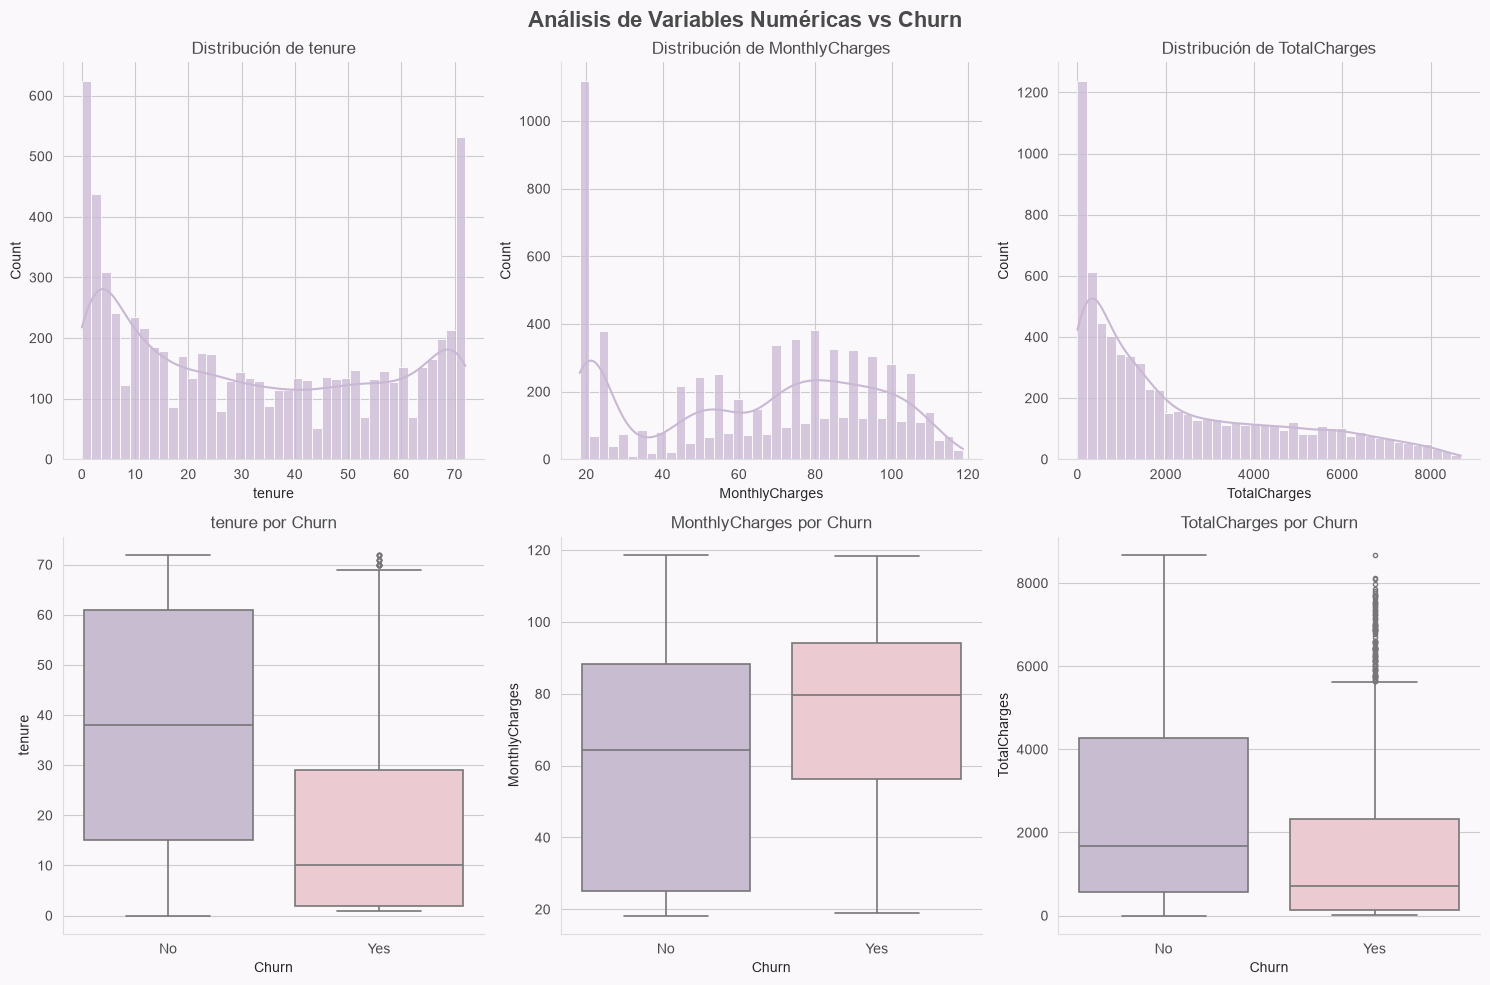


Estadísticas por grupo de Churn:
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No       38.0           64.43       1679.52
Yes      10.0           79.65        703.55


In [28]:
num_vars = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(2, 3, figsize=(15, 10), facecolor=BACKGROUND)
fig.suptitle("Análisis de Variables Numéricas vs Churn", 
             fontsize=16, fontweight="bold", color="#4A4A4A")

for i, var in enumerate(num_vars):
    axes[0, i].set_facecolor(BACKGROUND)
    sns.histplot(data=df, x=var, bins=40, kde=True,
                 ax=axes[0, i], color=SINGLE_COLOR, alpha=0.75)
    axes[0, i].set_title(f"Distribución de {var}", fontsize=12, color="#4A4A4A")
    axes[0, i].spines[["top", "right"]].set_visible(False)
    axes[0, i].spines[["left", "bottom"]].set_color("#DDDDDD")
    axes[0, i].tick_params(colors="#4A4A4A")

    axes[1, i].set_facecolor(BACKGROUND)
    sns.boxplot(data=df, x="Churn", y=var,
                ax=axes[1, i], palette=PALETTE,
                linewidth=1.2, flierprops=dict(marker='o', markersize=3,
                color="#AAAAAA"))
    axes[1, i].set_title(f"{var} por Churn", fontsize=12, color="#4A4A4A")
    axes[1, i].spines[["top", "right"]].set_visible(False)
    axes[1, i].spines[["left", "bottom"]].set_color("#DDDDDD")
    axes[1, i].tick_params(colors="#4A4A4A")

plt.tight_layout()
plt.savefig("../data/processed/03_numerical_variables.png", dpi=150, 
            bbox_inches="tight", facecolor=BACKGROUND)
plt.show()

# Estadísticas por grupo
print("\nEstadísticas por grupo de Churn:")
print(df.groupby("Churn")[num_vars].median().round(2))

**tenure (antigüedad):**
- Clientes que NO hacen churn tienen mediana ~38 meses
- Clientes que SÍ hacen churn tienen mediana ~10 meses
- **Conclusión:** los clientes nuevos son los más vulnerables — 
  la antigüedad es probablemente el predictor más potente del modelo

**MonthlyCharges (cargo mensual):**
- Clientes con churn pagan más al mes (~79$) vs los que se quedan (~65$)
- **Conclusión:** a mayor cargo mensual, mayor riesgo de abandono — 
  posiblemente relacionado con contratos Fiber optic más caros

**TotalCharges (cargo total acumulado):**
- Clientes con churn tienen TotalCharges menor — consecuencia directa 
  de que son clientes más nuevos (menos meses × menos cargos acumulados)
- Esta variable tiene alta correlación con tenure → posible multicolinealidad

**Decisión:** las tres variables son predictivas pero TotalCharges 
es parcialmente redundante con tenure. Evaluaremos su impacto 
en feature selection durante el modelado.

## 5. Variables Categóricas
Analizamos cómo se distribuye el churn según las variables categóricas.
El objetivo es identificar qué segmentos de clientes tienen mayor 
tasa de abandono — esto guiará el feature engineering posterior.

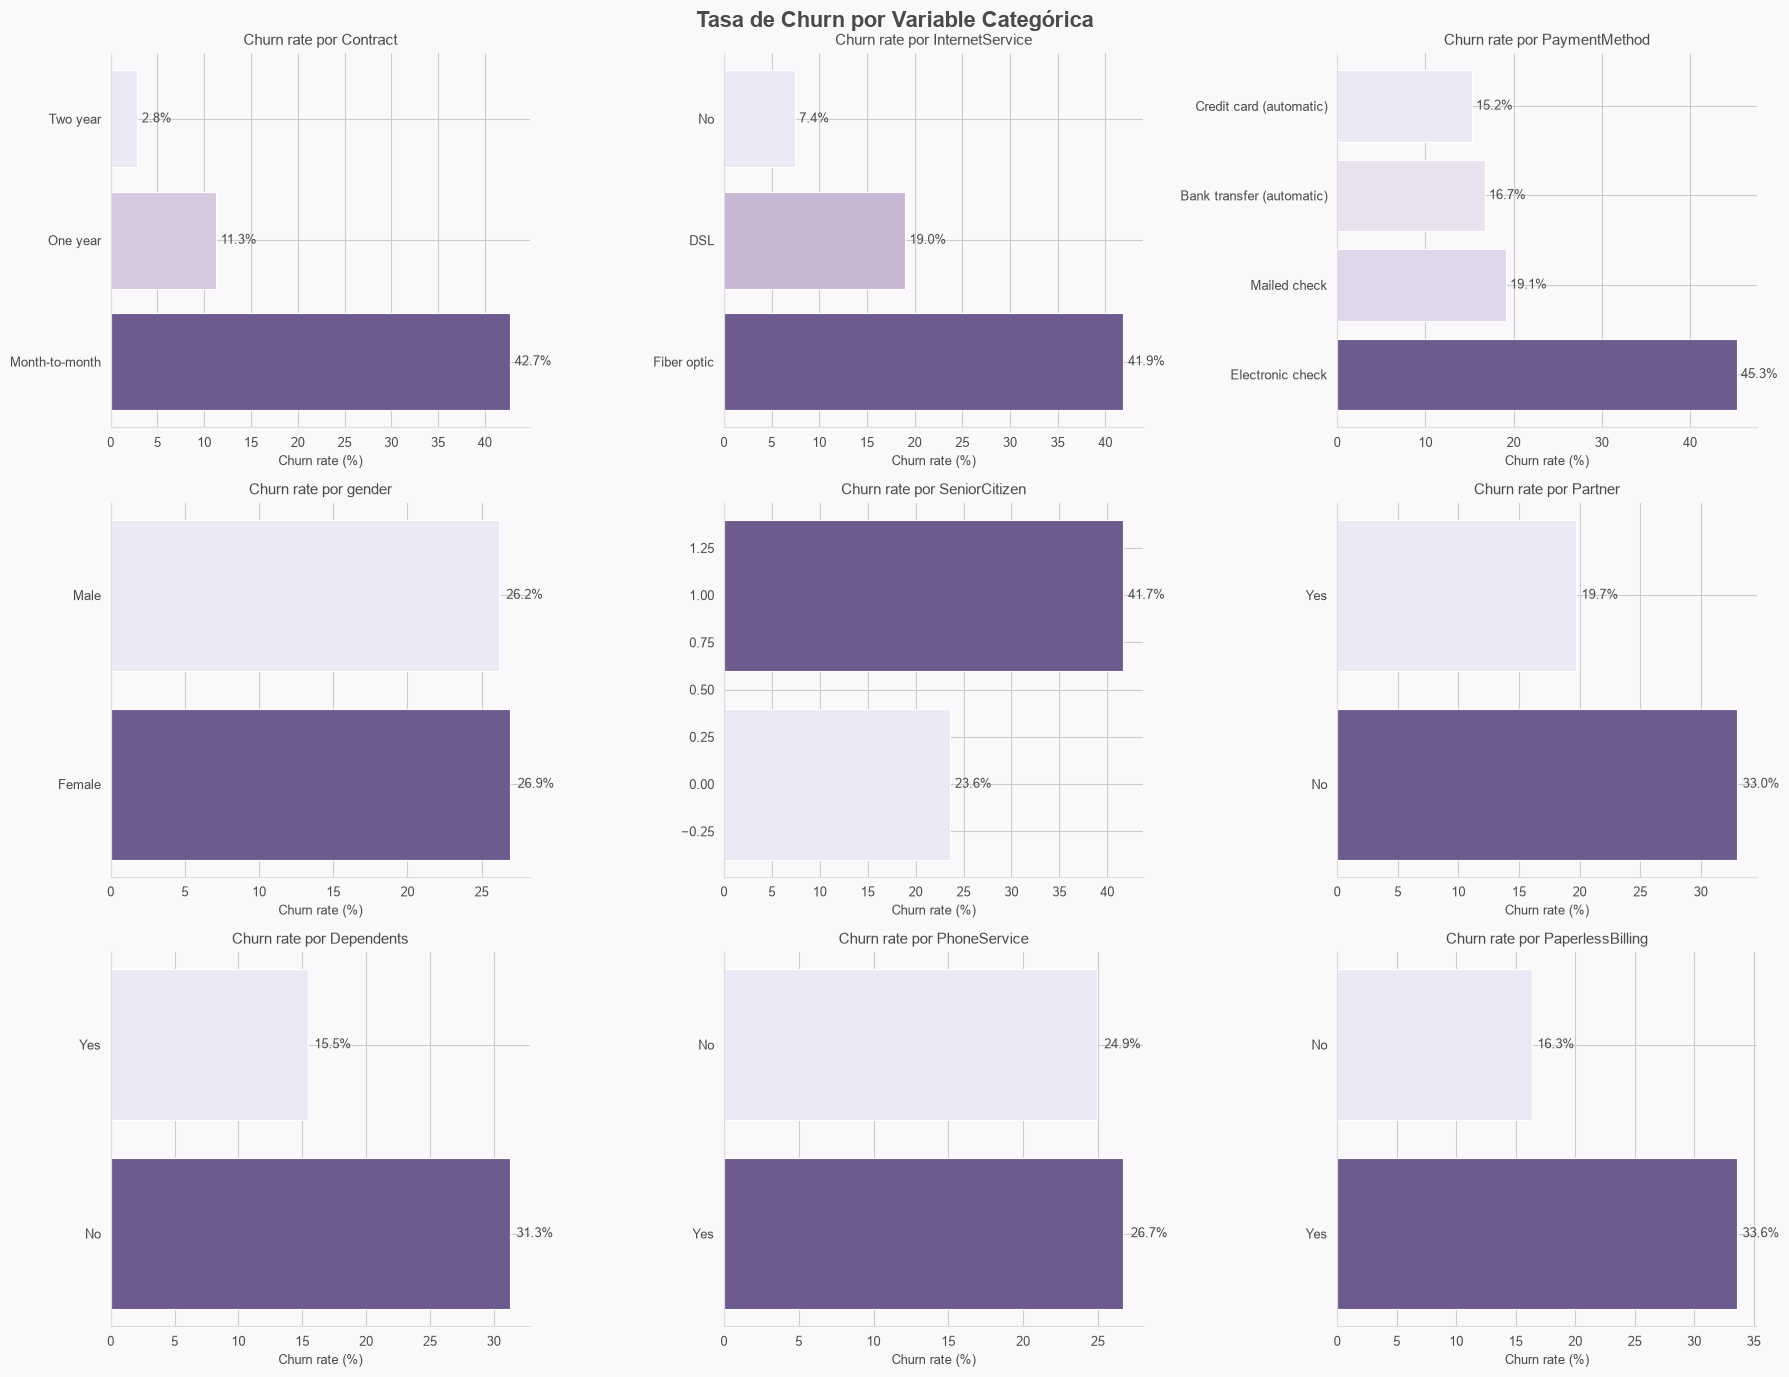


Churn rate por variable categórica clave:

Contract:
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8

InternetService:
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4

PaymentMethod:
PaymentMethod
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Electronic check             45.3
Mailed check                 19.1


In [31]:
cat_vars = ["Contract", "InternetService", "PaymentMethod", 
            "gender", "SeniorCitizen", "Partner", "Dependents",
            "PhoneService", "PaperlessBilling"]

fig, axes = plt.subplots(3, 3, figsize=(18, 14), facecolor=BACKGROUND)
fig.suptitle("Tasa de Churn por Variable Categórica", 
             fontsize=16, fontweight="bold", color="#4A4A4A")

axes = axes.flatten()

# Gradiente solo en familia malva-lavanda: claro → oscuro
cmap = LinearSegmentedColormap.from_list("churn", ["#EDE8F5", "#C9B8D4", "#9B89B4", "#6D5A8E"])

for i, var in enumerate(cat_vars):
    churn_rate = df.groupby(var)["Churn_binary"].mean().sort_values(ascending=False) * 100
    
    norm_vals = (churn_rate.values - churn_rate.values.min()) / (churn_rate.values.max() - churn_rate.values.min() + 1e-9)
    colors_grad = [cmap(v) for v in norm_vals]
    
    bars = axes[i].barh(churn_rate.index, churn_rate.values,
                        color=colors_grad, edgecolor="white", linewidth=0.8)
    axes[i].set_facecolor(BACKGROUND)
    axes[i].set_title(f"Churn rate por {var}", fontsize=11, color="#4A4A4A")
    axes[i].set_xlabel("Churn rate (%)", color="#4A4A4A", fontsize=9)
    axes[i].spines[["top", "right"]].set_visible(False)
    axes[i].spines[["left", "bottom"]].set_color("#DDDDDD")
    axes[i].tick_params(colors="#4A4A4A", labelsize=9)
    
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=9, color="#4A4A4A")

plt.tight_layout()
plt.savefig("../data/processed/04_categorical_churn_rates.png", 
            dpi=150, bbox_inches="tight", facecolor=BACKGROUND)
plt.show()

print("\nChurn rate por variable categórica clave:")
for var in ["Contract", "InternetService", "PaymentMethod"]:
    print(f"\n{var}:")
    print((df.groupby(var)["Churn_binary"].mean() * 100).round(1).to_string())

**Variables más predictivas:**
- `Contract` — diferencia de 40pp entre month-to-month (43%) y two year (3%). 
  Es el predictor categórico más potente del dataset
- `PaymentMethod` — electronic check tiene el mayor churn rate (45%). 
  Hipótesis: menor fricción para cancelar al no tener domiciliación bancaria
- `InternetService` — Fiber optic (~42%) duplica a DSL (~19%). 
  Posiblemente relacionado con precio y mayor competencia en ese segmento
- `SeniorCitizen` — clientes mayores de 65 años tienen ~42% de churn 
  vs 24% del resto

**Variables con efecto moderado:**
- `Partner` y `Dependents` — clientes con familia tienen ~15pp menos churn. 
  La responsabilidad familiar actúa como ancla de retención
- `PaperlessBilling` — perfil digital más propenso a comparar y cambiar

**Variables no significativas:**
- `gender` y `PhoneService` — churn rate prácticamente idéntico 
  entre categorías. Baja utilidad predictiva esperada

**Decisiones:**
- `Contract`, `InternetService` y `PaymentMethod` serán features clave
- `gender` podría eliminarse en feature selection
- Crearemos features combinadas: tenure × Contract, SeniorCitizen × InternetService

## 6. Matriz de Correlaciones
Analizamos las correlaciones entre variables numéricas y el target
para confirmar las relaciones observadas y detectar multicolinealidad.

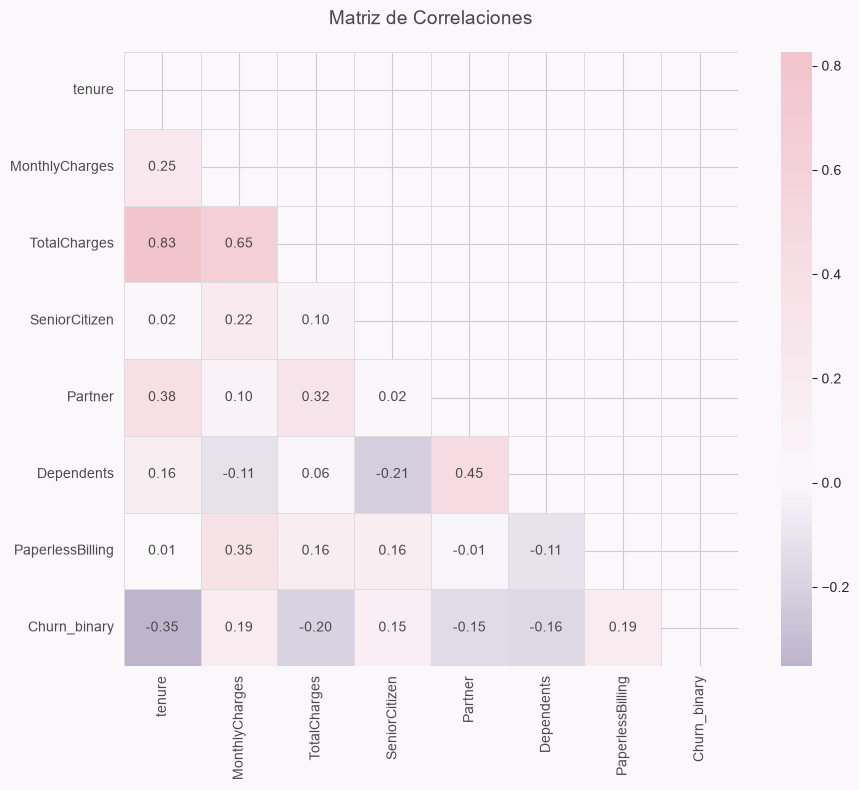


Correlaciones con Churn (ordenadas):
tenure             -0.352
TotalCharges       -0.198
MonthlyCharges      0.193
PaperlessBilling    0.192
Dependents         -0.164
SeniorCitizen       0.151
Partner            -0.150
Name: Churn_binary, dtype: float64


In [32]:
# Preparar datos numéricos para correlación
df_corr = df.copy()

# Encodear variables binarias simples para incluirlas
binary_map = {"Yes": 1, "No": 0}
for col in ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]:
    df_corr[col] = df_corr[col].map(binary_map)

# Seleccionar variables numéricas + target
corr_vars = ["tenure", "MonthlyCharges", "TotalCharges", 
             "SeniorCitizen", "Partner", "Dependents", 
             "PaperlessBilling", "Churn_binary"]

corr_matrix = df_corr[corr_vars].corr()

# Visualización
fig, ax = plt.subplots(figsize=(10, 8), facecolor=BACKGROUND)
ax.set_facecolor(BACKGROUND)

cmap_corr = LinearSegmentedColormap.from_list("corr", 
            ["#6D5A8E", "#EDE8F5", "#FAF8FB", "#EDE8F5", "#6D5A8E"])

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap=LinearSegmentedColormap.from_list("corr",
            ["#6D5A8E", "#FAF8FB", "#F2C4CE"]),
            center=0, square=True, linewidths=0.5,
            linecolor="#DDDDDD", ax=ax,
            annot_kws={"size": 10, "color": "#4A4A4A"})

ax.set_title("Matriz de Correlaciones", fontsize=14, 
             color="#4A4A4A", pad=20)
ax.tick_params(colors="#4A4A4A", labelsize=10)

plt.tight_layout()
plt.savefig("../data/processed/05_correlation_matrix.png", 
            dpi=150, bbox_inches="tight", facecolor=BACKGROUND)
plt.show()

# Correlaciones con el target ordenadas
print("\nCorrelaciones con Churn (ordenadas):")
print(corr_matrix["Churn_binary"].drop("Churn_binary")
      .sort_values(key=abs, ascending=False).round(3))

**Correlaciones con Churn:**
- `tenure` (-0.35) — correlación negativa más fuerte: más antigüedad, 
  menos churn. Confirma que es el predictor numérico más potente
- `MonthlyCharges` (0.19) — positiva: más cargo mensual, más churn
- `TotalCharges` (-0.20) — negativa pero es consecuencia de tenure, 
  no causa independiente
- `SeniorCitizen` (0.15) — confirma el efecto observado en categóricas

**Multicolinealidad detectada:**
- `TotalCharges` y `tenure` tienen correlación muy alta (~0.83) 
- `TotalCharges` y `MonthlyCharges` también correlacionan (~0.65)
- **Decisión:** evaluar eliminar `TotalCharges` en favor de `tenure` 
  y `MonthlyCharges` que son más interpretables y menos redundantes

**Variables poco correlacionadas con Churn:**
- `Partner`, `Dependents`, `PaperlessBilling` — correlación baja 
  individualmente pero pueden tener efecto combinado con otras variables

## 7. Conclusiones y Decisiones de Preprocesamiento

### Resumen de hallazgos clave

**Sobre el target:**
- Desbalance moderado 73/27 — no crítico pero requiere tratamiento
- Métrica principal: ROC-AUC + F1 sobre clase minoritaria. 
  Accuracy descartada como métrica principal

**Sobre la calidad del dato:**
- 11 filas con TotalCharges vacío → clientes con tenure=0, 
  imputados con 0 por coherencia de negocio
- Sin duplicados ni otros nulos

**Predictores más potentes identificados:**
1. `tenure` — el más importante numéricamente (corr -0.35)
2. `Contract` — diferencia de 40pp entre tipos de contrato
3. `InternetService` — Fiber optic duplica el churn de DSL
4. `PaymentMethod` — electronic check con mayor tasa de abandono
5. `MonthlyCharges` — a mayor cargo, mayor riesgo

**Variables de bajo valor predictivo:**
- `gender` — churn rate idéntico entre categorías
- `customerID` — identificador, se eliminará

---

### Decisiones de preprocesamiento

| Decisión | Justificación |
|---|---|
| Eliminar `customerID` | Identificador sin valor predictivo |
| Eliminar `gender` | Sin diferencia significativa en churn rate |
| Imputar `TotalCharges` nulos con 0 | Clientes nuevos sin cargos acumulados |
| Convertir `TotalCharges` a numérico | Vino como string por espacios en blanco |
| Encoding ordinal para `Contract` | Tiene orden natural: month < one year < two year |
| One-hot encoding para resto de categóricas | Sin orden natural |
| Evaluar eliminación de `TotalCharges` | Alta multicolinealidad con tenure (0.83) |
| `class_weight='balanced'` como baseline | Estrategia más simple para desbalance |
| Threshold tuning post-entrenamiento | Optimizar según coste de negocio FP vs FN |

---

### Próximos pasos
1. **Preprocessing pipeline** — implementar todas las decisiones anteriores 
   en `src/churn_pipeline/data/preprocessing.py`
2. **Feature engineering** — crear features combinadas:
   - `tenure_group` — segmentar tenure en grupos de negocio
   - `services_count` — número total de servicios contratados
   - `is_fiber_monthly` — interacción Fiber optic × MonthlyCharges
3. **Modelado** — baseline logistic regression → XGBoost con MLflow tracking